# E-commerce: Identifying Customer Profiles

# Introduction
Identifying customer profiles based on customer activities and purchasing behavior will be the main focus of this project.

**Objective**

Customer segmentation is a crucial strategy for e-commerce businesses. By grouping customers based on shared characteristics like demographics, interests, and shopping behaviors, companies can tailor marketing campaigns and product recommendations to specific segments. This targeted approach helps increase customer engagement, boost sales, and improve customer retention.

**Table of Contents**
1. Import Library and Dataset
2. Data Observation and Data Pre-Processing
3. Exploratory Data Analysis
4. User Segment
5. Hypothesis Testing
6. Conclusion

## Import Library and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as mt
from sklearn.cluster import KMeans
from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import warnings
warnings.simplefilter('ignore', FutureWarning)

In [2]:
try:
    df = pd.read_csv('/datasets/ecommerce_dataset_us.csv', sep='\t')
except:
    df = pd.read_csv('ecommerce_dataset_us.csv', sep='\t')

## Data Observation and Data Pre-Processing

### Data Observation

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 28.9+ MB


In [4]:
df['InvoiceDate'] = df['InvoiceDate'].astype('datetime64')

In [5]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
dtype: object

In [6]:
df.shape

(541909, 7)

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2018-11-29 08:26:00,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,2018-11-29 08:26:00,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2018-11-29 08:26:00,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2018-11-29 08:26:00,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2018-11-29 08:26:00,3.39,17850.0


In [8]:
df.duplicated().sum()

5268

df.isna().sum()

From the data observation results, the following conclusions were obtained:
1. The Quantity and CustomerID columns have null values in the dataset
2. There is 5268 duplicate data
3. Column naming does not follow the snake_case rules
4. The data type in the InvoiceDate column is changed to datetime

### Data Pre-Processing

#### Renaming Columns

Column names in the dataset will be replaced by following snake_case.

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID'],
      dtype='object')

In [11]:
df = df.rename(columns={
    'InvoiceNo':'invoice_no',
    'StockCode':'stock_code',
    'Description':'description',
    'Quantity':'quantity',
    'InvoiceDate':'invoice_date',
    'UnitPrice':'unit_price',
    'CustomerID':'customer_id'
})

In [12]:
df.columns

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id'],
      dtype='object')

#### Removing Duplicates

In [13]:
df.duplicated().sum()

5268

In [14]:
(df.duplicated().sum()/len(df))*100

0.9721189350979592

In [15]:
df = df.drop_duplicates().reset_index(drop=True)

In [16]:
df.duplicated().sum()

0

#### Filling in Missing Values

In [17]:
df.loc[df['customer_id'].isna()]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id
605,536414,22139,NaN,56,2018-11-29 11:52:00,0.00,NaN
1407,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2018-11-29 14:32:00,2.51,NaN
1408,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2018-11-29 14:32:00,2.51,NaN
1409,536544,21786,POLKADOT RAIN HAT,4,2018-11-29 14:32:00,0.85,NaN
1410,536544,21787,RAIN PONCHO RETROSPOT,2,2018-11-29 14:32:00,1.66,NaN
...,...,...,...,...,...,...,...
536275,581498,85099B,JUMBO BAG RED RETROSPOT,5,2019-12-07 10:26:00,4.13,NaN
536276,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2019-12-07 10:26:00,4.13,NaN
536277,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2019-12-07 10:26:00,4.96,NaN
536278,581498,85174,S/4 CACTI CANDLES,1,2019-12-07 10:26:00,10.79,NaN


In [18]:
(df.isna().sum())/len(df)*100

invoice_no       0.000000
stock_code       0.000000
description      0.270945
quantity         0.000000
invoice_date     0.000000
unit_price       0.000000
customer_id     25.163377
dtype: float64

From the calculation above, the description column has a missing value of 0.2%, so we can discard the missing value. For the customer_id column, it has a missing value of 25% of the entire dataset. This means that we cannot discard the value, but try to fill it by seeing whether there is a correlation with other columns in the same dataset.

In [19]:
check_column = df.loc[ (df['customer_id'].isna()) & (df['description'].isna())]

In [20]:
check_column.head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id
605,536414,22139,NaN,56,2018-11-29 11:52:00,0.0,NaN
1934,536545,21134,NaN,1,2018-11-29 14:32:00,0.0,NaN
1935,536546,22145,NaN,1,2018-11-29 14:33:00,0.0,NaN
1936,536547,37509,NaN,1,2018-11-29 14:33:00,0.0,NaN
1951,536549,85226A,NaN,1,2018-11-29 14:34:00,0.0,NaN
1952,536550,85044,NaN,1,2018-11-29 14:34:00,0.0,NaN
1984,536552,20950,NaN,1,2018-11-29 14:34:00,0.0,NaN
1985,536553,37461,NaN,3,2018-11-29 14:35:00,0.0,NaN
1986,536554,84670,NaN,23,2018-11-29 14:35:00,0.0,NaN
2362,536589,21777,NaN,-10,2018-11-29 16:50:00,0.0,NaN


In [21]:
(check_column.shape[0]/len(df))*100

0.2709446352403189

In [22]:
check_column['unit_price'].value_counts()

0.0    1454
Name: unit_price, dtype: int64

In [23]:
df['unit_price'].value_counts()

1.25      49750
1.65      37627
0.85      28182
2.95      27350
0.42      24277
          ...  
323.98        1
183.00        1
511.25        1
290.59        1
221.16        1
Name: unit_price, Length: 1630, dtype: int64

From the processing above, it is found that the missing value in the description column also has a missing value in the customer_id column, therefore we can discard data where the description value is null.

In [24]:
df = df.loc[ ~((df['customer_id'].isna()) & (df['description'].isna()))]

In [25]:
((df.isna().sum())/len(df))*100

invoice_no       0.000000
stock_code       0.000000
description      0.000000
quantity         0.000000
invoice_date     0.000000
unit_price       0.000000
customer_id     24.960061
dtype: float64

For now, the missing values are only in the customer_id column and the amount is still 24% of the entire dataset.

In [27]:
df = df.loc[ ~((df['customer_id'].isna()))]

The row with the empty Customer ID is dropped.

In [28]:
((df.isna().sum())/len(df))*100

invoice_no      0.0
stock_code      0.0
description     0.0
quantity        0.0
invoice_date    0.0
unit_price      0.0
customer_id     0.0
dtype: float64

In [29]:
df.dropna(inplace=True)

In [30]:
df.shape

(401604, 7)

In [31]:
df['customer_id'] = df['customer_id'].astype('int')
df['customer_id'] = df['customer_id'].astype('str')

In [32]:
df.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
dtype: int64

The missing values ​​have been successfully repaired.

#### stock_code Column

In [33]:
df.stock_code.sample(10)

349671    82483
131605    20733
470832    23582
505382    23241
191142    71477
165582    22111
373390    22457
252212    23109
518824    22741
239090    22457
Name: stock_code, dtype: object

In [34]:
((len(df.loc[(df.stock_code=='POST')]))/len(df))*100

0.2978057987470244

Since shipping costs are not included in the customer segment analysis and their percentage is also very small, we remove the stock_code column with the value "POST" - postage can be discarded.

In [35]:
df = df.loc[~(df.stock_code=='POST')]

In [36]:
((len(df.loc[(df.stock_code=='M')]))/len(df))*100

0.11488281952408542

For the same reason, the stock_code column with the value "M"-manual is discarded.

In [37]:
df = df.loc[~(df.stock_code=='M')]

The stock_code column was successfully repaired.

#### description Column

In [38]:
df.description.sample(10)

288065               REGENCY SUGAR BOWL GREEN
489267     GARDENERS KNEELING PAD CUP OF TEA 
256115         PINK/WHITE CHRISTMAS TREE 60CM
487836        GIN & TONIC DIET GREETING CARD 
167251             RED RETROSPOT SHOPPING BAG
420963               GINGHAM HEART DECORATION
73330          ROSE FOLKART HEART DECORATIONS
340381     SET OF 3 WOODEN SLEIGH DECORATIONS
492990    SET OF 60 PANTRY DESIGN CAKE CASES 
422599           ROCKING HORSE RED CHRISTMAS 
Name: description, dtype: object

In [39]:
df.description = df.description.str.lower()

In [40]:
df.description.head()

0     white hanging heart t-light holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4         red woolly hottie white heart.
Name: description, dtype: object

In [41]:
df.groupby('description').agg('nunique').sort_values(by='quantity', ascending=False).head(10)

,invoice_no,stock_code,quantity,invoice_date,unit_price,customer_id
description,,,,,,
popcorn holder,668,1,64,661,3,296
white hanging heart t-light holder,2013,1,60,1996,6,858
regency cakestand 3 tier,1884,1,58,1868,6,887
rabbit night light,816,1,56,806,4,450
jumbo bag red retrospot,1643,1,52,1631,9,636
small popcorn holder,417,1,43,415,2,228
paper chain kit 50's christmas,990,1,42,981,3,615
wooden star christmas scandinavian,436,1,42,436,3,334
assorted colour bird ornament,1385,1,42,1375,2,679


In [42]:
df.loc[df.description.str.contains('damages|damaged', regex=True), 'description'].unique()

array([], dtype=object)

In [43]:
df.loc[df.description.str.contains('damages|damaged', regex=True), 'description'] = 'damaged'

In [44]:
df.loc[df.description.str.contains('\?', regex=True), 'description'].unique()

array([], dtype=object)

In [45]:
df.loc[df.description.str.contains('\?', regex=True), 'description'] = 'missing'

In [46]:
df.loc[df.description.str.contains('check', regex=True), 'description'].unique()

array(['brown check cat doorstop ', 'pair padded hangers pink check',
       'sunset check hammock', 'blue crusoe check lampshade',
       'blue check bag w handle 34x20cm'], dtype=object)

In [47]:
df.loc[df.description.str.contains('brown check cat doorstop ', regex=True), 'description'] = 'brown cat doorstop'
df.loc[df.description.str.contains('pair padded hangers pink check', regex=True), 'description'] = 'pair padded hangers pink'
df.loc[df.description.str.contains('sunset check hammock', regex=True), 'description'] = 'sunset hammock'
df.loc[df.description.str.contains('blue crusoe check lampshade', regex=True), 'description'] = 'blue crusoe lampshade'
df.loc[df.description.str.contains('blue check bag w handle 34x20cm', regex=True), 'description'] = 'blue bag w handle 34x20cm'

In [48]:
df.loc[df.description.str.contains('check', regex=True), 'description'] = 'check'

In [49]:
len(df.loc[df.description.str.contains('check|damaged|missing|found', regex=True), 'description'])

0

In [50]:
df = df.loc[~(df.description.str.contains('check|demaged|missing|found', regex=True))]

In [51]:
df['description'] = df['description'].str.strip()

In [52]:
df.groupby('description').agg('nunique').sort_values(by='quantity', ascending=False).tail(20)

,invoice_no,stock_code,quantity,invoice_date,unit_price,customer_id
description,,,,,,
set/6 ivory bird t-light candles,1,1,1,1,1,1
jam jar with blue lid,1,1,1,1,1,1
"letter ""o"" bling key ring",1,1,1,1,1,1
"wall art,only one person",1,1,1,1,1,1
storage tin vintage doiley,1,1,1,1,1,1
green drop earrings w bead cluster,1,1,1,1,1,1
light decoration battery operated,1,1,1,1,1,1
easter craft ivy wreath with chick,1,1,1,1,1,1
"letter ""z"" bling key ring",1,1,1,1,1,1


The description column has been successfully repaired, by modifying the capitalization to lowercase, changing the name to make it easier to group, and deleting some unnecessary data. The number of data deleted is 402 rows.

#### quantity Column

In [53]:
df.quantity.sample(10)

400886    15
145212    72
332693     1
511363     1
291644     6
235956     6
183944    25
39609     12
396188     3
311726     3
Name: quantity, dtype: int64

In [54]:
df.quantity = abs(df.quantity)

In [55]:
df.loc[df.quantity<0]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id


The negative value in the quantity column has been successfully changed to positive.

#### Checking Outliers

In [56]:
df.describe()

,quantity,unit_price
count,399948.000000,399948.000000
mean,13.563636,2.986345
std,250.689735,8.848471
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,1867.860000


Judging from the large standard deviation value compared to the average, there may be outliers in the dataset.

In [57]:
def delete_outlier (data, column_name):
    
    df_clean = data
    
    for col in column_name:
        
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        
        IQR = Q3 - Q1
        minimum = Q1 - 1.5*IQR
        maximum = Q3 + 1.5*IQR
        
        df_clean = df_clean.loc[(df_clean[col] >= minimum) & (df_clean[col] <= maximum)]
    return df_clean

In [58]:
df_update = delete_outlier (data = df, column_name = ['quantity', 'unit_price'])

In [59]:
df_update.describe()

,quantity,unit_price
count,339645.000000,339645.000000
mean,7.498523,2.202528
std,6.770713,1.549253
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.650000
75%,12.000000,2.950000
max,27.000000,7.500000


#### Adding Columns to a Dataset

- Date Column

In [60]:
df_update['date'] = df_update['invoice_date'].dt.date

In [61]:
df_update.head(3)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,date
0,536365,85123A,white hanging heart t-light holder,6,2018-11-29 08:26:00,2.55,17850,2018-11-29
1,536365,71053,white metal lantern,6,2018-11-29 08:26:00,3.39,17850,2018-11-29
2,536365,84406B,cream cupid hearts coat hanger,8,2018-11-29 08:26:00,2.75,17850,2018-11-29


- Category Column

In [62]:
X = df_update[['quantity', 'unit_price']]

In [63]:
scaler = StandardScaler()

In [64]:
X_sc = scaler.fit_transform(X)

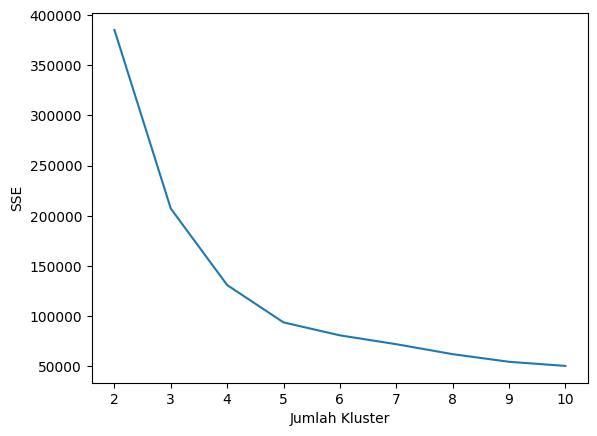

In [65]:
range_n_clusters = range(2,11)

sse = []
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(X_sc)
    sse.append(clusterer.inertia_)

plt.plot(range_n_clusters, sse)

plt.xlabel('Jumlah Kluster')
plt.ylabel('SSE')

plt.show()

According to the elbow graph above, the number of clusters is 3.

In [66]:
km_model = KMeans(n_clusters=3, random_state=0)

km_model.fit(X_sc)

predicted_clusters = km_model.predict(X_sc)

In [67]:
df_update['cluster_km'] = predicted_clusters

In [68]:
percentage = 100 - ((df_update.shape[0]/541909)*100)
print('Initial dataset size (541909, 7)')
print('Final dataset size {}'.format(df_update.shape))
print('Percentage change {:.2f}%'.format(percentage))

Initial dataset size (541909, 7)
Final dataset size (339645, 9)
Percentage change 37.32%


Changing capital letters to lowercase letters in the column.
1. Changing capital letters to lowercase letters in the column.
2. Filling in missing values based on the relationship with values ​​from other columns.
3. Duplication has been fixed.
4. Outliers in the data have been fixed.


## EDA

### Metrics

#### Store Income

In [69]:
df_update.sample(5)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,date,cluster_km
129197,547485,84997B,childrens cutlery retrospot red,2,2019-03-21 11:16:00,4.15,17019,2019-03-21,0
300066,563430,84804A,cream delphinium artificial flower,24,2019-08-14 11:50:00,2.95,14918,2019-08-14,2
127844,547372,22084,paper chain kit empire,1,2019-03-20 13:46:00,2.95,16374,2019-03-20,1
127558,547358,21908,chocolate this way metal sign,2,2019-03-20 12:25:00,2.10,15998,2019-03-20,1
8418,537137,22355,charlotte bag suki design,10,2018-12-03 12:43:00,0.85,16327,2018-12-03,2


In [70]:
df_update['revenue'] = df_update['quantity'] * df_update['unit_price']

In [71]:
daily_revenue = df_update.groupby('date').agg({
    'revenue': 'sum'
})

daily_revenue

,revenue
date,
2018-11-29,20762.17
2018-11-30,23022.00
2018-12-01,11302.71
2018-12-03,20784.54
2018-12-04,18647.70
...,...
2019-12-03,32647.69
2019-12-04,23840.09
2019-12-05,26008.38


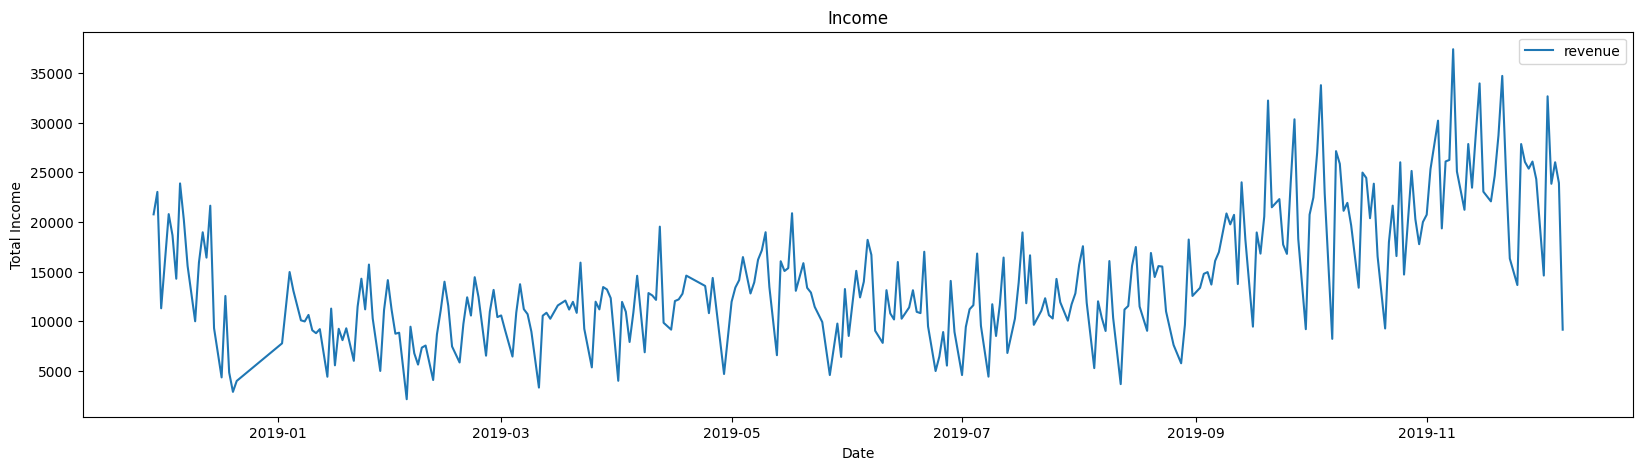

In [72]:
plt.figure(figsize=(20,5))

sns.lineplot(data=daily_revenue)

plt.title('Income')

plt.xlabel('Date')
plt.ylabel('Total Income')

plt.show()

It can be seen that the daily revenue trend is increasing. This indicates an increase in customers' daily purchases.

#### Average Purchase

In [73]:
daily_avg_order = df_update.groupby('date').agg({
    'quantity': 'mean',
})

daily_avg_order

,quantity
date,
2018-11-29,6.815740
2018-11-30,7.581056
2018-12-01,6.749722
2018-12-03,4.611158
2018-12-04,5.733813
...,...
2019-12-03,6.834869
2019-12-04,6.867019
2019-12-05,8.825774


In [74]:
daily_avg_order.describe()

,quantity
count,305.000000
mean,7.628656
std,1.419465
min,3.697464
25%,6.929564
50%,7.867282
75%,8.652557
max,10.494915


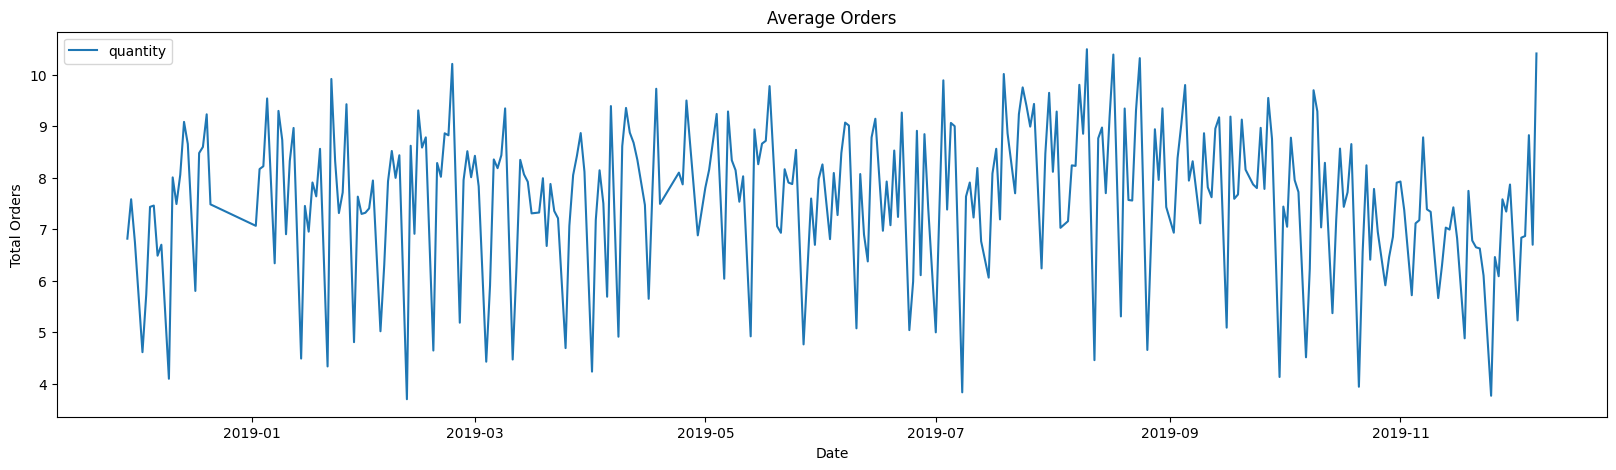

In [75]:
daily_avg_order.plot(kind='line', figsize=(20,5))

plt.title('Average Orders')

plt.xlabel('Date')
plt.ylabel('Total Orders')

plt.show()

The average purchase size for the period was 6.32, the maximum purchase size was 10.15, and the average purchase size was 2.96. The trend on the chart shows that there has been no significant increase in purchase volume and the trend is likely to remain stable.

#### Month-over-Month Trend In Average Revenue per User

In [76]:
df_update['month'] = df_update['invoice_date'].dt.to_period('M')

In [77]:
rev_per_user = df_update.groupby(['customer_id','month']).agg({
    'revenue':'sum'
})

rev_per_user

revenue
customer_id month           
12347       2018-12   650.89
            2019-01   437.14
            2019-04   325.00
            2019-06   351.82
            2019-07   342.66
...                      ...
18283       2019-10    88.54
            2019-11   637.71
            2019-12   208.00
18287       2019-05   440.28
            2019-10   520.48

[12886 rows x 1 columns]

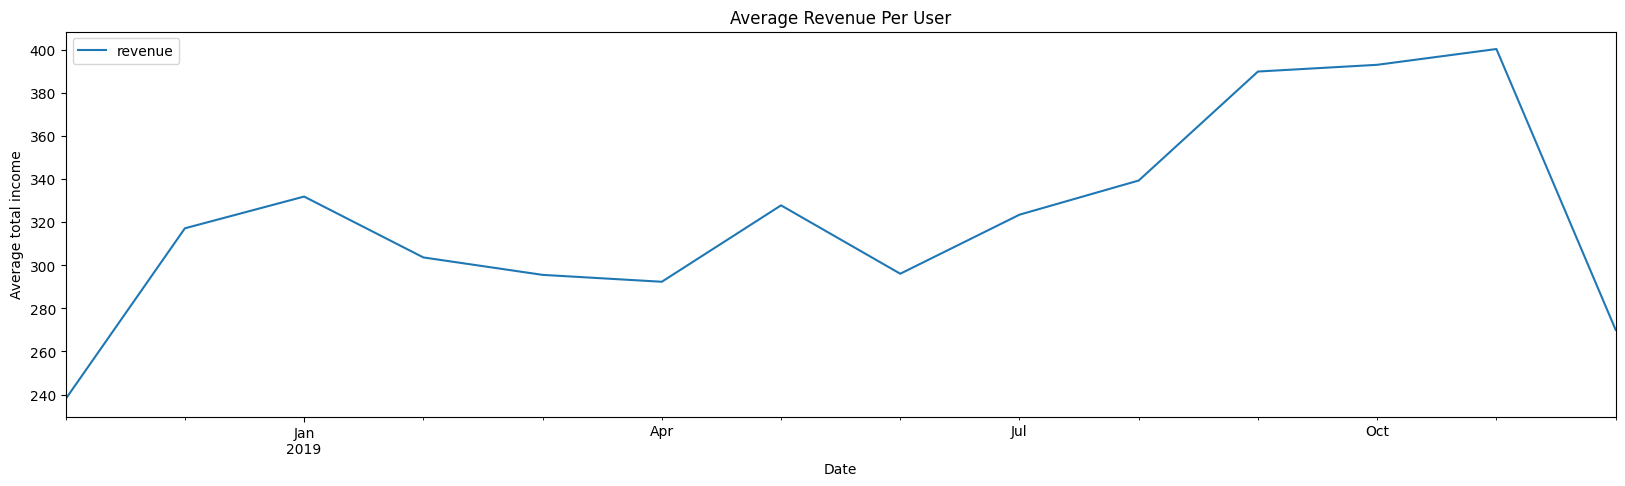

In [78]:
rev_per_user.groupby('month').mean().plot(kind='line', figsize=(20,5))

plt.title('Average Revenue Per User')

plt.xlabel('Date')
plt.ylabel('Average total income')

plt.show()

It can be observed that the average revenue per user increases every month. This shows that user purchasing activity is increasing every month. There is a positive trend in daily revenue and average revenue per user from month to month. This shows an increase in purchasing activity by customers and users.

## User Segment

### Cluster

In [79]:
df_update.groupby(['cluster_km']).mean()

,quantity,unit_price,revenue
cluster_km,,,
0,3.739222,4.718548,17.721443
1,3.338638,1.717731,5.984565
2,15.196134,1.299561,18.780692


Cluster 0 has the most orders, the lowest unit cost value, and the highest total value. Conversely, cluster 1 has the fewest orders, the highest unit cost value, and a lower total value than cluster 0. Cluster 2 has fewer orders than cluster 0, a lower unit cost value than cluster 1, and the lowest total value of any cluster.

In [80]:
def avg_revenue_user (data):
    orders = data[['invoice_date', 'customer_id', 'revenue']]
    
    first_order_date = orders.groupby('customer_id').agg({
        'invoice_date':'min'
    })

    first_order_date = first_order_date.rename(columns=({
        'invoice_date' : 'first_invoice_date'
    }))
    
    orders = orders.join(first_order_date, on='customer_id')
    
    orders['invoice_month'] = orders['invoice_date'].astype('datetime64[M]')

    orders['first_invoice_month'] = orders['first_invoice_date'].astype('datetime64[M]')
    
    orders_grouped_by_cohorts = orders.groupby(['first_invoice_month', 'invoice_month']).agg({
        'revenue': 'sum',
        'customer_id': 'nunique'
    }).reset_index()
    
    orders_grouped_by_cohorts['revenue_per_user'] = (
        orders_grouped_by_cohorts['revenue']
        / orders_grouped_by_cohorts['customer_id']
    )
    
    orders_grouped_by_cohorts['cohort_lifetime'] = (
        orders_grouped_by_cohorts['invoice_month']
        - orders_grouped_by_cohorts['first_invoice_month']
    )
    
    orders_grouped_by_cohorts['cohort_lifetime'] = orders_grouped_by_cohorts[
        'cohort_lifetime'
    ] / np.timedelta64(1, 'M')
    
    orders_grouped_by_cohorts['cohort_lifetime'] = (
        orders_grouped_by_cohorts['cohort_lifetime'].round().astype('int')
    )
    
    orders_grouped_by_cohorts['first_invoice_month'] = orders_grouped_by_cohorts['first_invoice_month'].dt.strftime('%Y-%m')
    
    revenue_per_user_pivot = orders_grouped_by_cohorts.pivot_table(
        index='first_invoice_month',
        columns='cohort_lifetime',
        values='revenue_per_user',
        aggfunc='mean',
    )
    
    plt.figure(figsize=(13, 9))

    sns.heatmap(
        revenue_per_user_pivot,
        annot=True,
        fmt='.1f',
        linewidths=1,
        linecolor='gray',
    )

    plt.title('Revenue per user')

    plt.xlabel('Cohort cycle')
    plt.ylabel('Cohort')

    return plt.show()

The function above is a function to create a cohort heatmap for each user cluster.


Klaster 0:


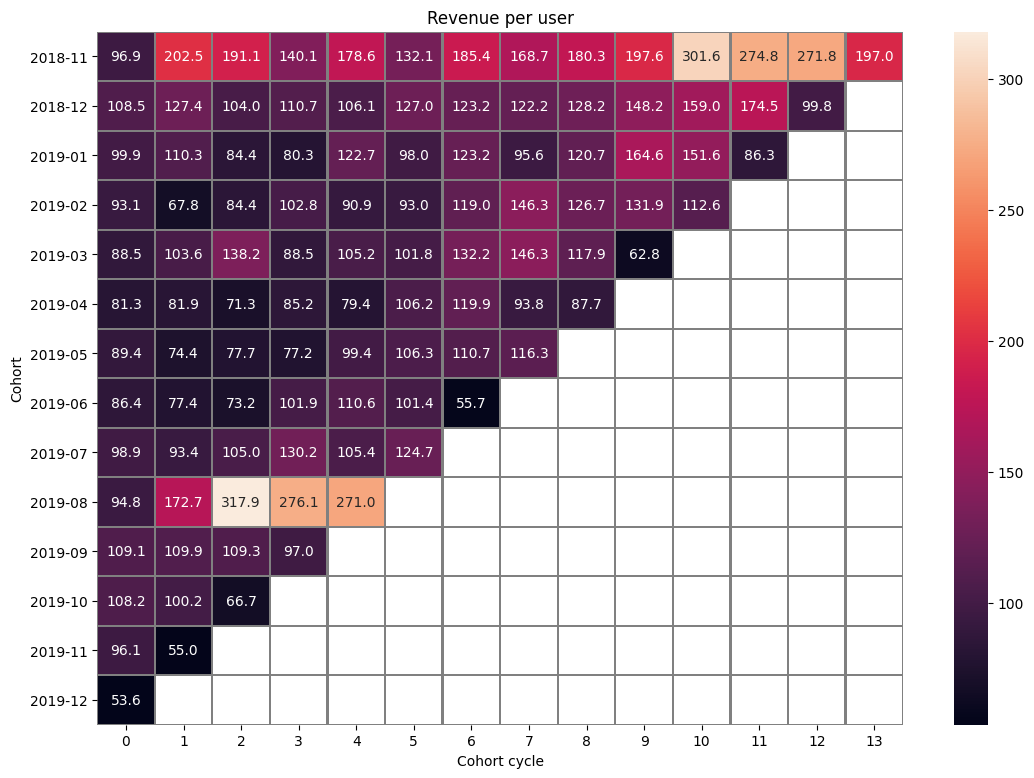


Klaster 1:


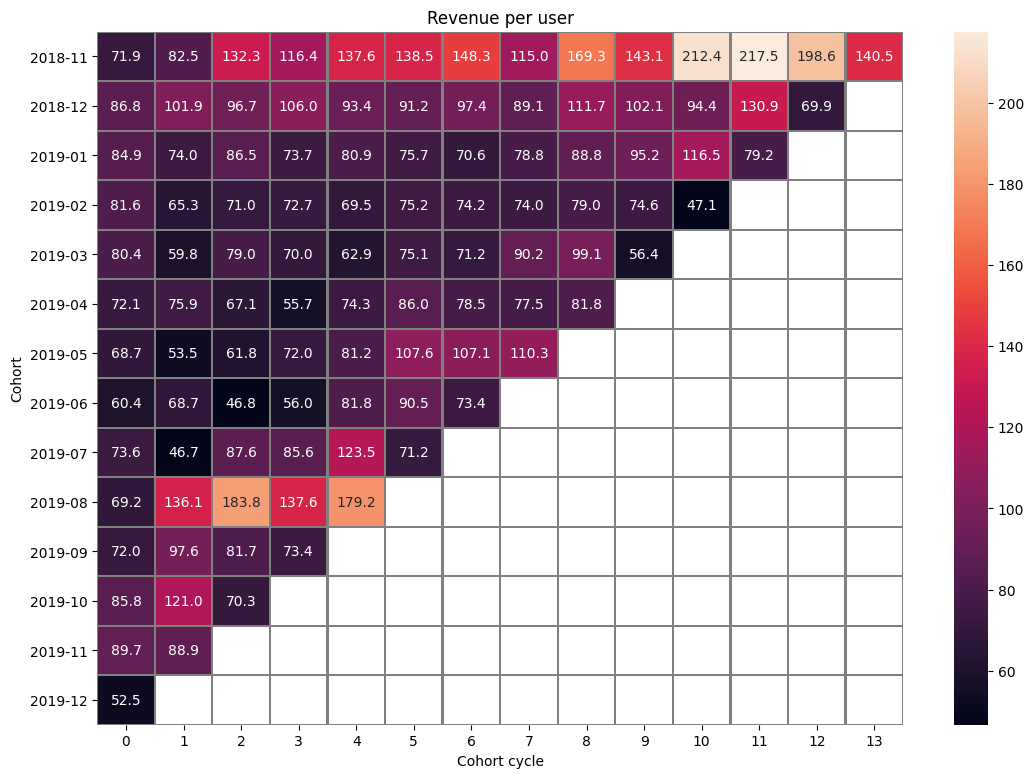


Klaster 2:


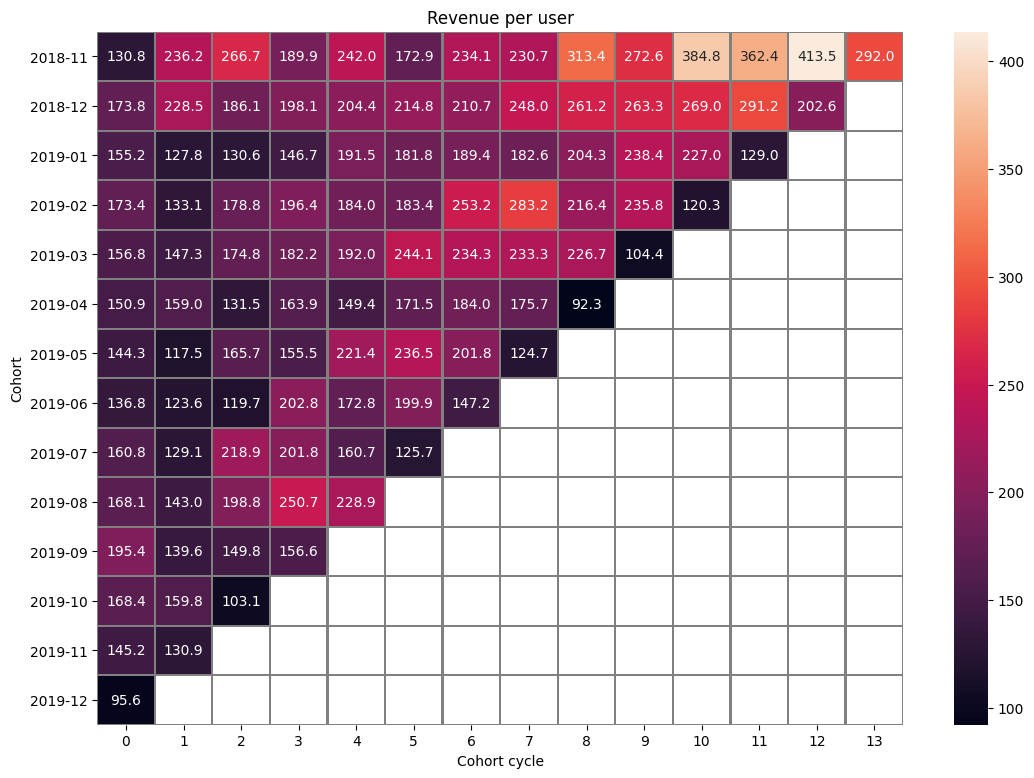

In [81]:
for i in range(3):
    print(f"\nKlaster {i}:")
    avg_revenue_user(data=df_update[df_update['cluster_km'] == i])

Of all the clusters, the 2018-11 cohort has higher user income compared to other cohorts. This indicates a seasonal purchasing period, peaking at month 12 of the life cycle, indicating the possibility of repeat purchases during this period, although the amount of sales varies, but all clusters show the maximum cohort value.

### Products and Order Quantity

In [82]:
product_preference = df_update.groupby(['cluster_km', 'description']).agg({
    'revenue':'sum',
    'quantity':'mean'
}).reset_index()

In [83]:
product_preference = product_preference.sort_values(['cluster_km', 'revenue'], ascending=[True, False])

In [84]:
for i in range(3):
    
    print(f"\nKlaster {i}:")
    
    display(product_preference[product_preference['cluster_km']==i].head(5))


Klaster 0:


,cluster_km,description,revenue,quantity
794,0,party bunting,33055.65,5.305622
1132,0,spotty bunting,22056.50,4.600619
599,0,jam making set with jars,20362.25,5.616423
1025,0,set of 3 cake tins pantry design,18517.27,3.253022
560,0,home building block word,15077.60,3.656652



Klaster 1:


,cluster_km,description,revenue,quantity
3885,1,white hanging heart t-light holder,17665.65,4.449963
2791,1,natural slate heart chalkboard,10667.50,4.692607
3325,1,roses regency teacup and saucer,8756.45,4.634945
3919,1,wooden frame antique white,8402.60,4.313725
3922,1,wooden picture frame white finish,8355.90,4.365651



Klaster 2:


,cluster_km,description,revenue,quantity
5171,2,jumbo bag red retrospot,22785.92,12.075922
4115,2,assorted colour bird ornament,14880.45,18.192149
6521,2,white hanging heart t-light holder,14444.85,14.042857
5303,2,lunch bag red retrospot,14349.95,11.588549
5143,2,jam making set printed,11675.26,13.734483


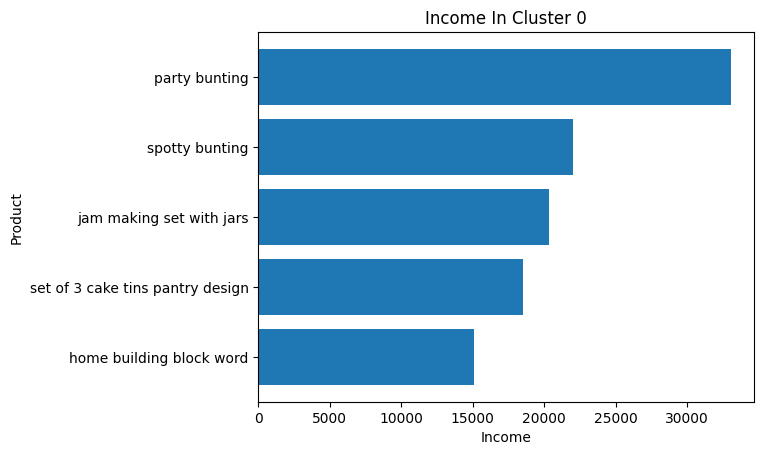

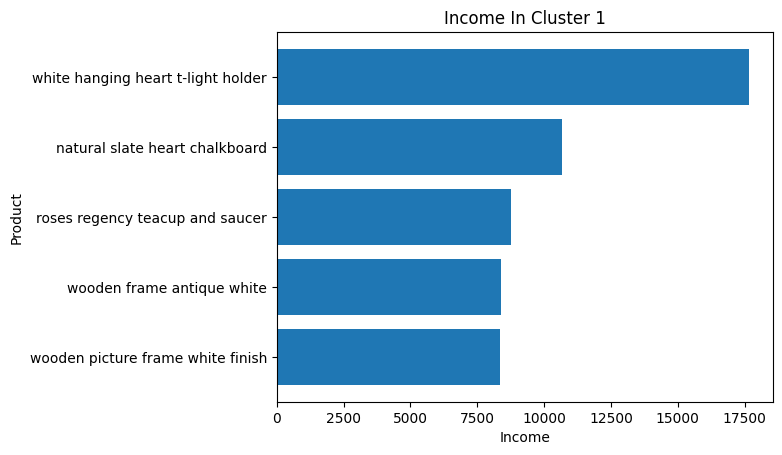

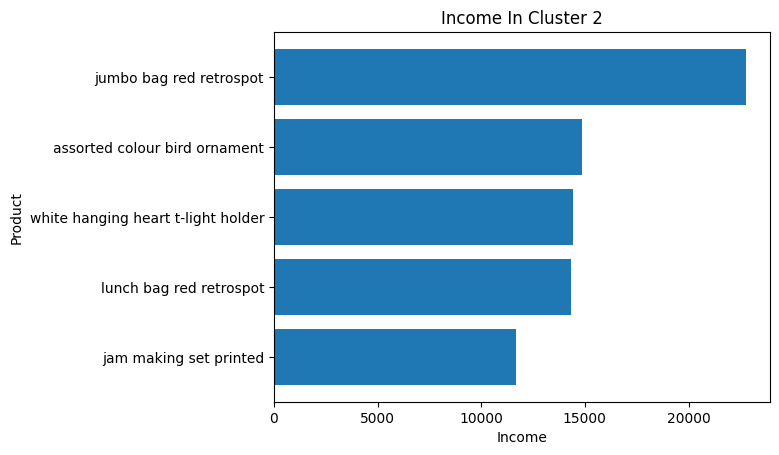

In [85]:
for i in range(3):
    
    fig, ax = plt.subplots()
    
    ax.invert_yaxis()
    
    products = product_preference[product_preference['cluster_km'] == i].head(5)
    
    ax.barh(products['description'], products['revenue'])
    
    plt.title(f"Income In Cluster {i}")
    
    plt.xlabel("Income")
    plt.ylabel("Product")
    
    plt.show()

From the results above, the products with the highest sales in each cluster are:
- jumbo bag retrosport in cluster 0
- white hanging heart t-light holder in cluster 1
- party bunting in cluster 2

## Testing Hypothesis

### Difference in statistics of cluster order sizes 0 and 2

The null hypothesis (H0) and alternative hypothesis (H1) must be determined first.
- H0: The average order size of cluster 0 and cluster 2 is the same.
- H1: The average order size of cluster 0 and cluster 2 is not the same.

If H0 defines the average order size of cluster 0 and cluster 2 is 'SAME', then H1 will define the opposite of H0, namely the average order size of cluster 0 and cluster 2 is 'NOT SAME'.

The alpha used is 5%.

In [86]:
cluster_0 = df_update.loc[df_update['cluster_km'] == 0]
cluster_2 = df_update.loc[df_update['cluster_km'] == 2]

In [87]:
quantity_0 = cluster_0.groupby('customer_id').agg({
    'quantity':'mean'
}).reset_index()

quantity_2 = cluster_2.groupby('customer_id').agg({
    'quantity':'mean'
}).reset_index()

In [88]:
np.var(quantity_0['quantity'])

6.454583774774555

In [89]:
np.var(quantity_2['quantity'])

9.533469995864499

In [90]:
alpha = 0.05

results = st.ttest_ind(quantity_0['quantity'], quantity_2['quantity'], equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print('We cannot ignore the null hypothesis') 

p-value: 0.0
We reject the null hypothesis


Because the p-value is smaller than alpha, the null hypothesis is rejected, which means that statistically the average income of users in cluster 0 and cluster 2 is different.

## Conclusion

The conclusions from the above data processing are as follows:
- Daily turnover and average turnover per user are growing positively every month. This indicates an increase in the purchasing activity of customers and users. Therefore, it is advisable to take advantage of this trend by creating special offers or promotions to increase the number and value of transactions.
- At the same time, it is observed that the purchase volume generally remains stable and does not show any peaks worth mentioning. Therefore, further analysis is recommended to find out which factors influence the size of purchases and can strengthen the positive development of revenue.
- There are seasonal purchasing periods where repeat purchases are possible. Therefore, it is advisable to make special offers or promotions during this time to increase sales.